In [1]:
import pandas as pd
import numpy as np
import re
from dateutil import parser
import string

# Load dataset
file_path = '/content/synthetic_tweets_us_unlabeled.csv'
df = pd.read_csv(file_path)

# ------------------- Robust Date Parsing -------------------
def robust_date_parse(date_str):
    try:
        dt = parser.parse(date_str, fuzzy=True)
        return dt
    except Exception:
        return pd.NaT

df['parsed_created_at'] = df['created_at'].apply(robust_date_parse)
df['parsed_account_created_at'] = df['account_created_at'].apply(robust_date_parse)

In [2]:


# ------------------- Text Cleaning -------------------
def clean_text(text):
    if pd.isna(text):
        return text
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Normalize punctuation by replacing all with spaces
    text = text.translate(str.maketrans(string.punctuation, ' '*len(string.punctuation)))
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase text for uniformity
    text = text.lower()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [3]:
# ------------------- Extract Hashtags, Mentions, URLs -------------------
def extract_hashtags(text):
    if pd.isna(text):
        return []
    return re.findall(r'#\w+', text)

def extract_mentions(text):
    if pd.isna(text):
        return []
    return re.findall(r'@\w+', text)

def extract_urls(text):
    if pd.isna(text):
        return []
    return re.findall(r'http\S+|www\S+|https\S+', text)

df['hashtags'] = df['text'].apply(extract_hashtags)
df['mentions'] = df['text'].apply(extract_mentions)
df['urls'] = df['text'].apply(extract_urls)

In [4]:

# ------------------- Missing Data Handling -------------------
# Show missing counts
missing_summary = df.isna().sum()

# Fill missing in critical text-related columns if needed (for example, empty lists for hashtags/mentions)
df['hashtags'] = df['hashtags'].apply(lambda x: x if isinstance(x, list) else [])
df['mentions'] = df['mentions'].apply(lambda x: x if isinstance(x, list) else [])
df['urls'] = df['urls'].apply(lambda x: x if isinstance(x, list) else [])
df['clean_text'] = df['clean_text'].fillna('')

In [5]:
# ------------------- Data Type Cleanup -------------------
# Convert follower counts etc. to numeric if needed
num_cols = ['retweet_count', 'favorite_count', 'followers_count', 'statuses_count']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Check unique languages encoding and location - they may have some cleaning later if needed
df['lang'] = df['lang'].fillna('unknown')

# ------------------- Final Sanity Check -------------------
print("Missing data summary:\n", missing_summary)
print("\nData types after cleanup:\n", df.dtypes)

# Preview processed data
df[['parsed_created_at', 'parsed_account_created_at', 'clean_text', 'hashtags', 'mentions', 'urls']].head()


Missing data summary:
 tweet_id                       0
user_id                        0
username                       0
created_at                     0
text                           0
retweet_count                  0
favorite_count                 0
followers_count                0
statuses_count                 0
account_created_at             0
location                     311
is_retweet                     0
lang                           0
parsed_created_at             62
parsed_account_created_at      0
clean_text                     0
hashtags                       0
mentions                       0
urls                           0
dtype: int64

Data types after cleanup:
 tweet_id                             object
user_id                              object
username                             object
created_at                           object
text                                 object
retweet_count                         int64
favorite_count                        int64
f

,parsed_created_at,parsed_account_created_at,clean_text,hashtags,mentions,urls
0,2024-11-11 07:47:13,2014-10-15,ghost voters found in vote tallies 297 suspicious,[],[],[]
1,2024-11-14 03:08:59,2015-05-19,update clean election in my precinct,[],[],[]
2,2024-11-09 20:16:34,2024-08-29,early voting numbers — observers reporting ord...,[],[],[]
3,2024-11-03 08:21:06,2024-07-05,update transparent count in my precinct,[],[],[]
4,2024-11-14 02:44:18,2025-03-30,update observers confirm fairness in my precin...,[#VoteSafe],[],[]


**Inference from Data Preprocessing:**

The initial data loading and preprocessing steps were successful. Key observations include:

*   **Missing Data:** The `location` column has a significant number of missing values (311 out of 3000), while `parsed_created_at` also has a smaller number (62). Other columns have no missing values.
*   **Date Parsing:** The `robust_date_parse` function successfully converted `created_at` and `account_created_at` to datetime objects, with only a few errors in `created_at` as indicated by the missing values in `parsed_created_at`.
*   **Text Cleaning:** The `clean_text` function appears to have effectively removed URLs, normalized punctuation, collapsed spaces, and lowercased the text.
*   **Extraction of Features:** Hashtags, mentions, and URLs were successfully extracted into separate list columns. Missing values in these columns were handled by filling with empty lists.
*   **Data Type Conversion:** Numeric columns like retweet, favorite, follower, and status counts were successfully converted to integers, with any non-numeric values coerced to 0.
*   **Language Handling:** Missing language values were filled with 'unknown'.

Overall, the data is now in a cleaner and more usable format for further analysis, although the missing location data might require additional handling depending on subsequent tasks. The presence of missing parsed dates in `parsed_created_at` should also be noted for time-series analysis.

Account Age and Tweet Type

In [6]:
from datetime import timedelta

# Calculate account age in days at the time of tweet
df['account_age_days'] = (df['parsed_created_at'] - df['parsed_account_created_at']).dt.days
df['account_age_days'] = df['account_age_days'].fillna(-1).astype(int)  # Use -1 if date missing

# Create boolean for retweet and reply detection
df['is_retweet'] = df['is_retweet'].fillna(False).astype(bool)

# Normalize language codes (lowercase)
df['lang'] = df['lang'].str.lower().fillna('unknown')

# Preview
df[['parsed_created_at', 'parsed_account_created_at', 'account_age_days', 'is_retweet', 'lang']].head()


,parsed_created_at,parsed_account_created_at,account_age_days,is_retweet,lang
0,2024-11-11 07:47:13,2014-10-15,3680,False,es
1,2024-11-14 03:08:59,2015-05-19,3467,False,en
2,2024-11-09 20:16:34,2024-08-29,72,False,es
3,2024-11-03 08:21:06,2024-07-05,121,False,en-us
4,2024-11-14 02:44:18,2025-03-30,-136,False,en


In [7]:
def bot_score_heuristic(row):
    score = 0
    # Few followers may indicate bot
    if row['followers_count'] < 50:
        score += 1
    # Very high statuses might indicate bot activity
    if row['statuses_count'] > 1000:
        score += 1
    # Very young account age is suspicious
    if row['account_age_days'] != -1 and row['account_age_days'] < 30:
        score += 1
    return score

df['bot_score'] = df.apply(bot_score_heuristic, axis=1)


In [8]:
# Define keyword sets
angry_keywords = {'fraud', 'rigged', 'fake', 'stolen', 'scam', 'cheat'}
supportive_keywords = {'fair', 'trust', 'orderly', 'transparent', 'accurate'}

def sentiment_heuristic(text):
    text_lower = text.lower()
    if any(word in text_lower for word in angry_keywords):
        return 'angry'
    elif any(word in text_lower for word in supportive_keywords):
        return 'supportive'
    else:
        return 'neutral'

df['sentiment'] = df['clean_text'].apply(sentiment_heuristic)


Feature Engineering

Chunk 1: Compute TF-IDF representation of cleaned text



In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Define TF-IDF vectorizer (limit features for performance)
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')

# Learn TF-IDF on cleaned text
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f"TF-IDF shape: {tfidf_matrix.shape}")


TF-IDF shape: (3000, 247)


Chunk 2: Perform LDA topic modeling on TF-IDF matrix



In [10]:
from sklearn.decomposition import LatentDirichletAllocation

# Number of topics
num_topics = 6

# Fit LDA model on TF-IDF matrix
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_output = lda_model.fit_transform(tfidf_matrix)

# Assign dominant topic id to each document(tweet)
df['dominant_topic'] = lda_output.argmax(axis=1)

# Show top words for each topic
def get_top_words(model, vectorizer, n=10):
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics.append(top_features)
    return topics

topic_top_words = get_top_words(lda_model, tfidf_vectorizer)
for i, words in enumerate(topic_top_words):
    print(f"Topic {i}: {', '.join(words)}")


Topic 0: precinct, update, election, clean, transparent, fairness, confirm, count, observers, election2024
Topic 1: voter, steady, area, turnout, silent, officials, widely, share, evidence, rolls
Topic 2: poll, report, watchers, evidence, points, fraud, alert, precincts, electionfraud, investigate
Topic 3: voting, incoming, official, figures, smooth, numbers, early, update, tallies, suspicious
Topic 4: reporting, orderly, observers, process, counting, ongoing, update, polling, turnout, votesafe
Topic 5: trust, reports, investigated, precincts, precinct, process, update, illegal, votes, increíble


Chunk 3: Misinformation anomaly detection with IsolationForest on TF-IDF



In [11]:
from sklearn.ensemble import IsolationForest

# Train IsolationForest to detect anomalies (potential misinformation)
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # Adjust contamination as needed
df['misinfo_anomaly_score'] = iso_forest.fit_predict(tfidf_matrix)
df['misinfo_score'] = iso_forest.decision_function(tfidf_matrix)

# Convert anomaly score: -1 means anomaly, 1 means normal
df['misinfo_anomaly'] = df['misinfo_anomaly_score'].map({1: 0, -1: 1})

# Display top 10 most anomalous tweets (lowest decision_function scores)
top_anomalous = df.nsmallest(10, 'misinfo_score')[['text', 'misinfo_score', 'misinfo_anomaly']]
print(top_anomalous)


                                                   text  misinfo_score  \
1192  Evidence of ballot stuffing — officials silent...      -0.031188   
2211  Evidence of ballot stuffing — officials silent...      -0.031188   
1653  Reports of ballot stuffing in several precinct...      -0.029406   
314   early voting numbers — observers reporting ord...      -0.028103   
626   early voting numbers — observers reporting ord...      -0.028103   
74    poll watchers report — observers reporting ord...      -0.026677   
2742  Evidence of ballot stuffing — officials silent...      -0.022415   
2963  Evidence of ballot stuffing — officials silent...      -0.022415   
495   Evidence of voter rolls compromised — official...      -0.022214   
1606  ALERT: counting ongoing across precincts — evi...      -0.021671   

      misinfo_anomaly  
1192                1  
2211                1  
1653                1  
314                 1  
626                 1  
74                  1  
2742             

Chunk 4: Coordinated Campaign Detection



In [13]:
# Round timestamps to 5-minute windows (correcting deprecation warning)
df['time_window_5min'] = df['parsed_created_at'].dt.floor('5min')

# Group by time window and clean text, find texts posted multiple times
grouped = df.groupby(['time_window_5min', 'clean_text']).agg({
    'user_id': 'nunique',
    'text': 'count',
    'clean_text': 'first'
}).rename(columns={'clean_text': 'first_clean_text'}).reset_index()

# Filter groups with multiple users posting the same text in the window
coordinated_campaigns = grouped[grouped['user_id'] > 1].sort_values(['time_window_5min', 'user_id'], ascending=[True, False])

print(f"Identified coordinated campaigns in {coordinated_campaigns.shape[0]} groups")

# Save top sample for reporting
top_coordinated = coordinated_campaigns.head(10)
top_coordinated[['time_window_5min', 'first_clean_text', 'user_id']]

Identified coordinated campaigns in 58 groups


,time_window_5min,first_clean_text,user_id
18,2024-10-26 09:55:00,update observers confirm fairness in my precinct,2
393,2024-10-29 08:05:00,voter turnout steady in my area,2
483,2024-10-29 22:10:00,voter turnout steady in my area,2
593,2024-10-30 18:25:00,alert fake ballots across precincts — evidence...,4
594,2024-10-30 18:25:00,alert fake ballots across precincts — evidence...,2
595,2024-10-30 18:30:00,alert fake ballots across precincts — evidence...,4
596,2024-10-30 18:30:00,alert fake ballots across precincts — evidence...,4
725,2024-10-31 19:35:00,voter turnout steady in my area,2
846,2024-11-01 18:25:00,poll watchers report — observers reporting ord...,2
918,2024-11-02 06:25:00,alert fraudulent tabulation across precincts —...,3


Chunk 5: User Similarity Network



User similarity network has 926 nodes and 10243 edges


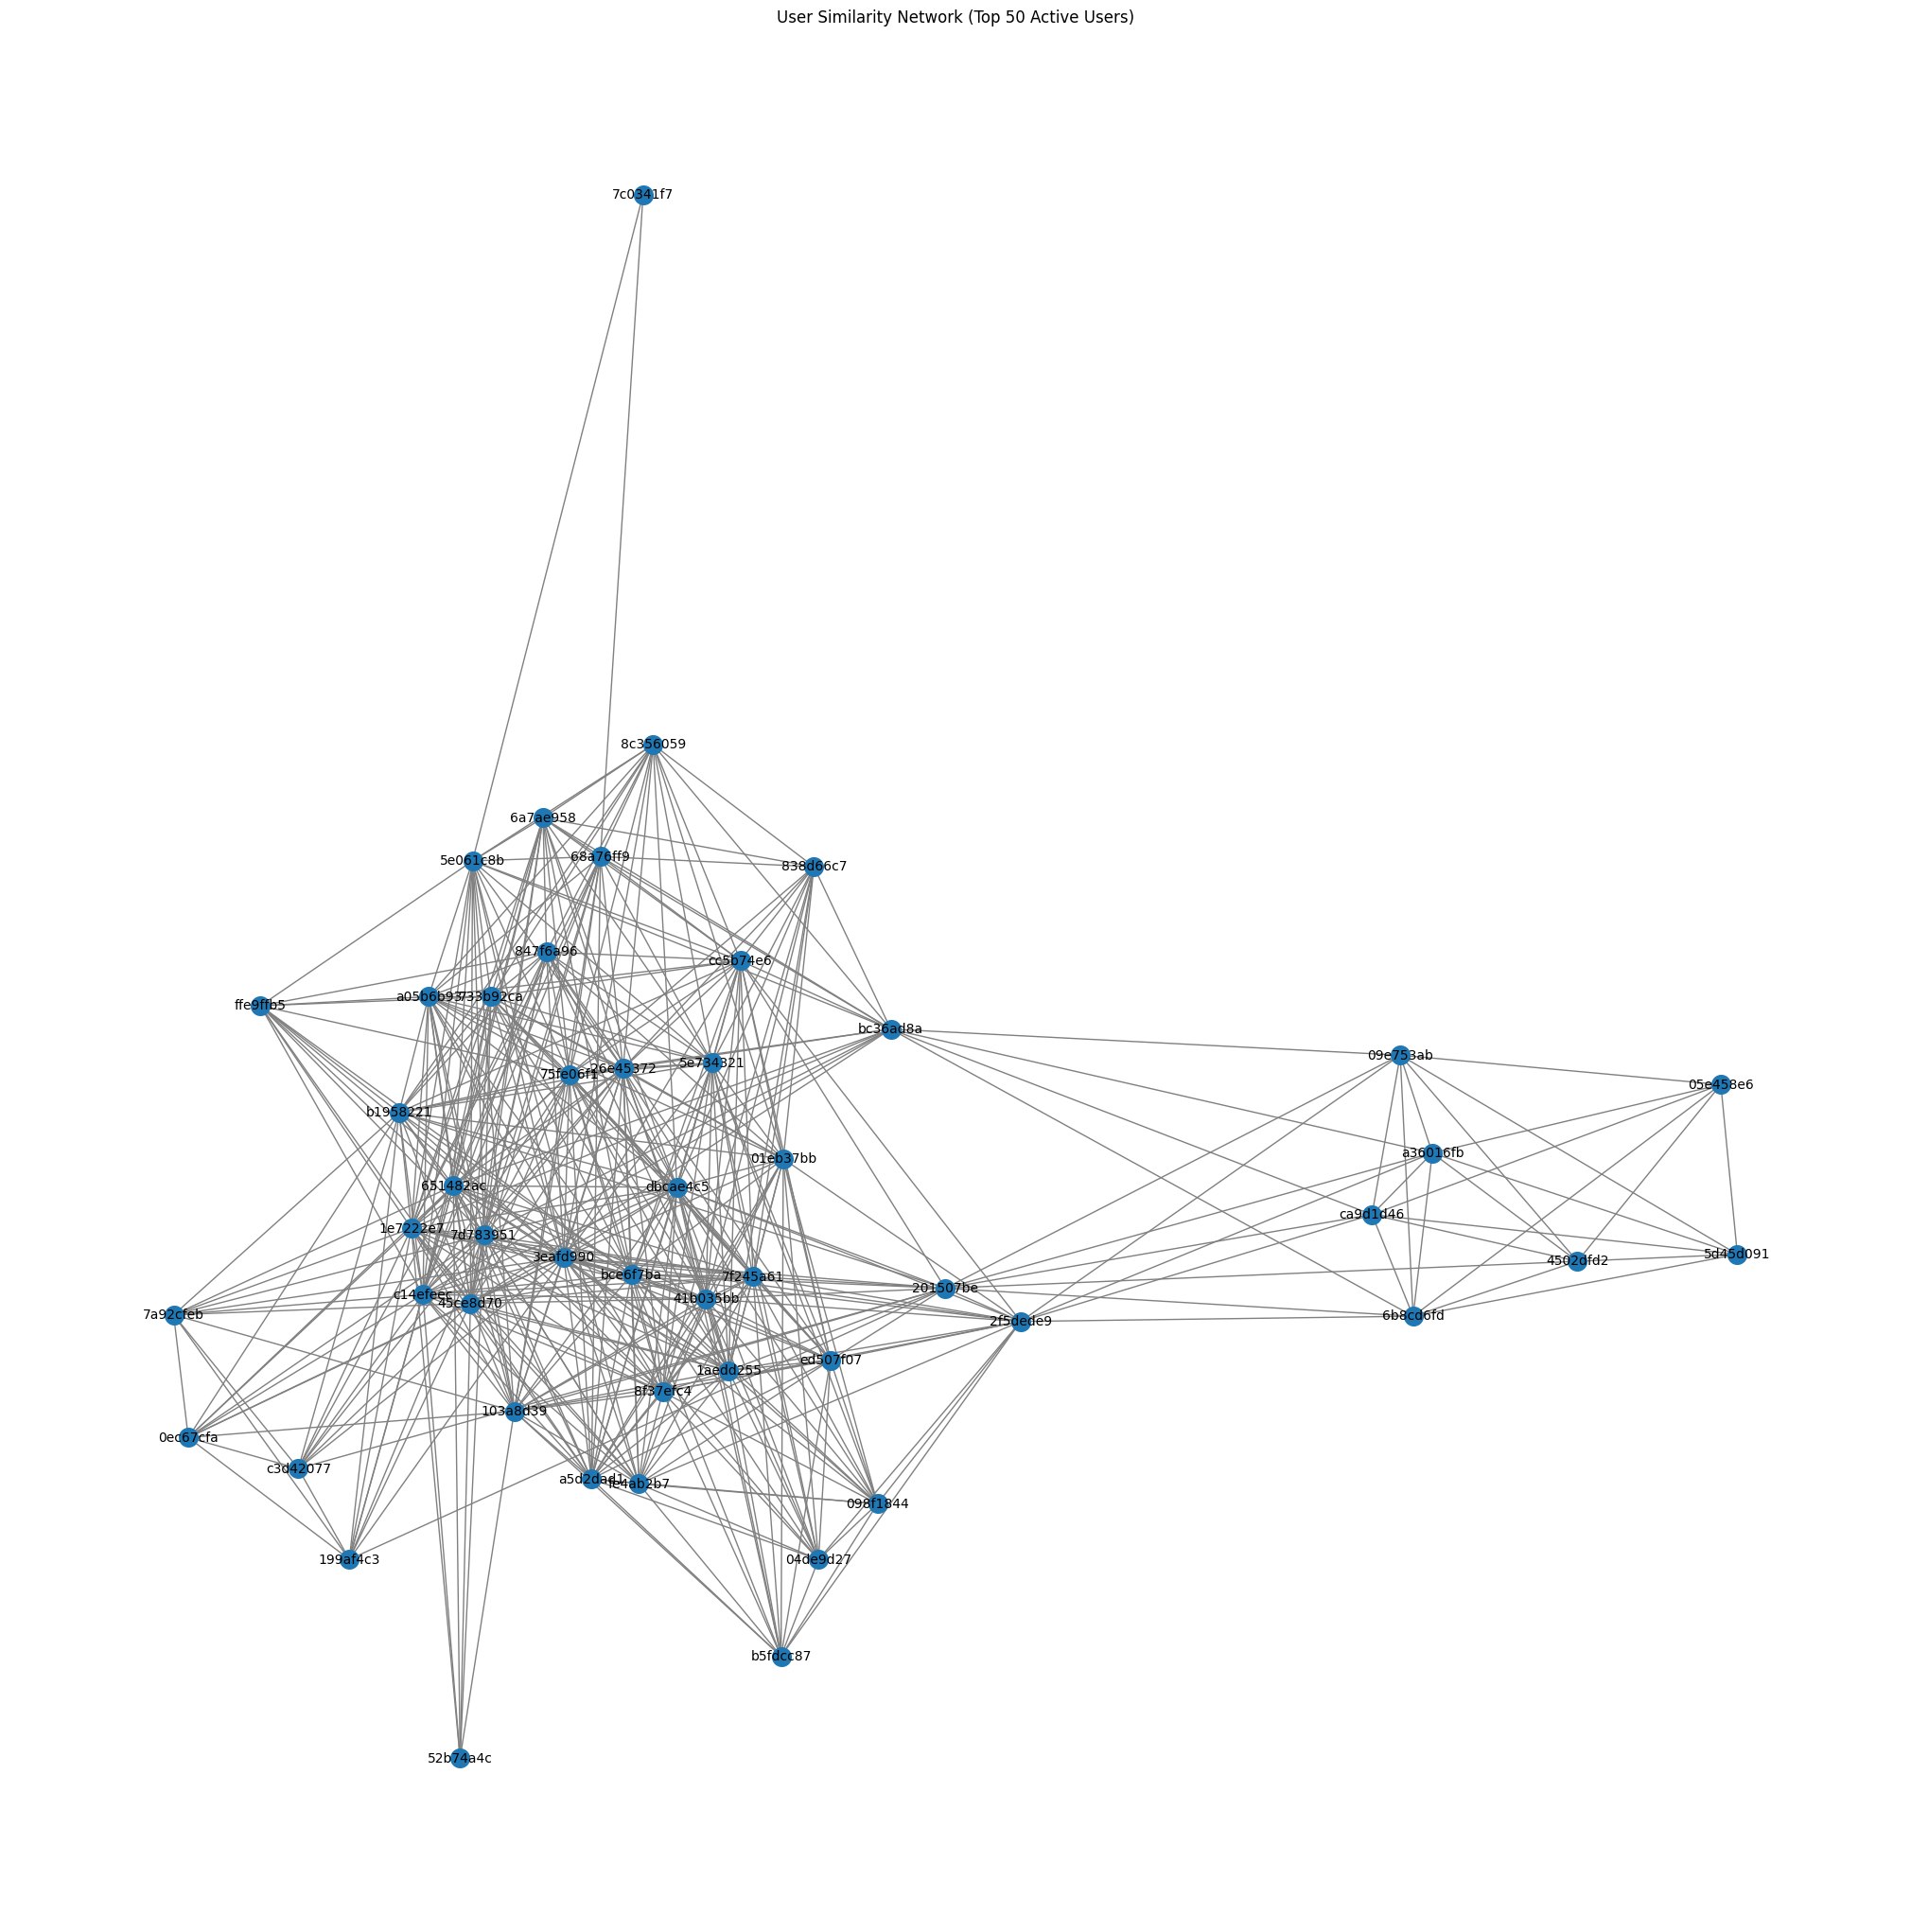

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt

# Aggregate all clean_text by user
user_texts = df.groupby('user_id')['clean_text'].apply(lambda x: ' '.join(x)).reset_index()

# TF-IDF on aggregated user texts
user_tfidf = TfidfVectorizer(max_features=500, stop_words='english').fit_transform(user_texts['clean_text'])

# Compute cosine similarity matrix
cosine_sim = cosine_similarity(user_tfidf)

# Build graph for users with similarity > threshold (e.g., 0.7)
threshold = 0.7
G = nx.Graph()

for i in range(len(user_texts)):
    for j in range(i + 1, len(user_texts)):
        if cosine_sim[i, j] > threshold:
            G.add_edge(user_texts['user_id'][i], user_texts['user_id'][j], weight=cosine_sim[i,j])

print(f"User similarity network has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Plot graph for top 50 nodes by degree
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:50]
top_user_ids = [n for n, d in top_nodes]

subgraph = G.subgraph(top_user_ids)
plt.figure(figsize=(20, 20)) # Increase figure size
pos = nx.spring_layout(subgraph, k=0.5) # Adjust layout for better spacing
nx.draw(subgraph, pos, with_labels=True, node_size=200, font_size=10, edge_color='gray') # Increase node and font size
plt.title('User Similarity Network (Top 50 Active Users)')
plt.show()

Chunk 6: Visualizations



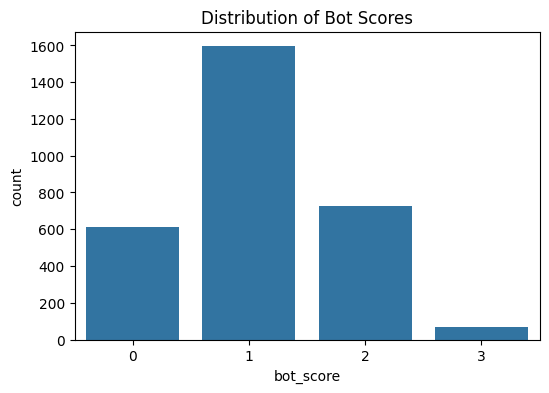

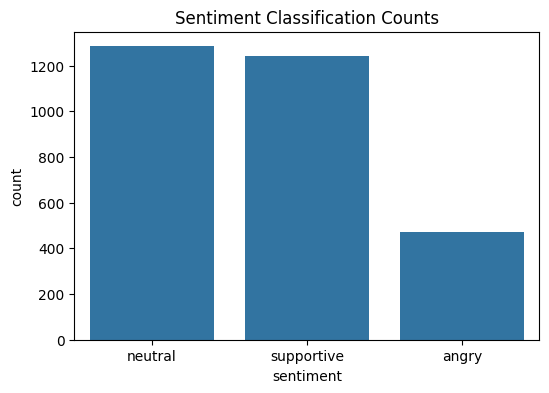

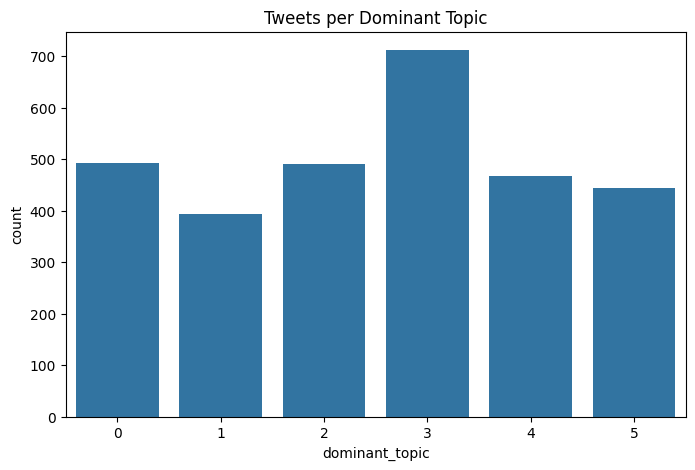

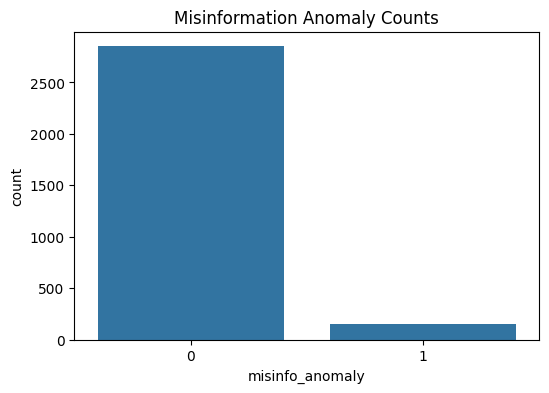

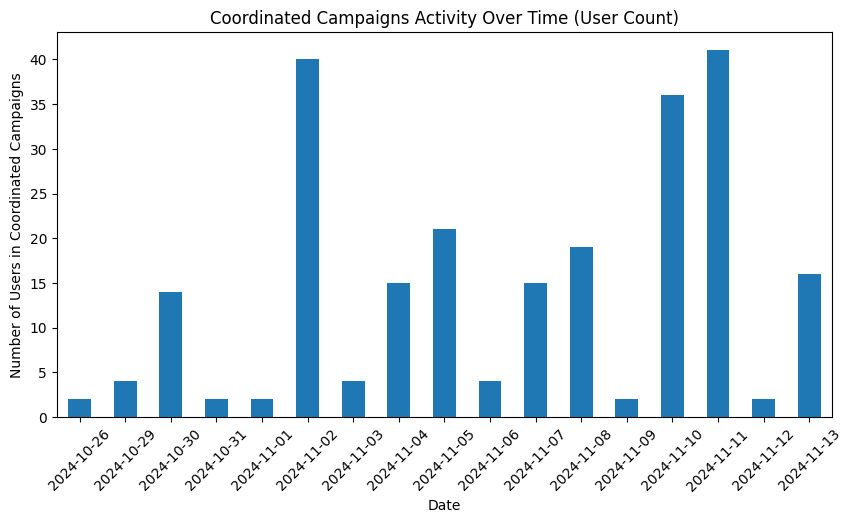

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Bot Scores
plt.figure(figsize=(6,4))
sns.countplot(x='bot_score', data=df)
plt.title('Distribution of Bot Scores')
plt.show()

# Sentiment counts
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Classification Counts')
plt.show()

# Tweets per dominant topic
plt.figure(figsize=(8,5))
sns.countplot(x='dominant_topic', data=df)
plt.title('Tweets per Dominant Topic')
plt.show()

# Misinformation anomaly counts
plt.figure(figsize=(6,4))
sns.countplot(x='misinfo_anomaly', data=df)
plt.title('Misinformation Anomaly Counts')
plt.show()

# Number of coordinated campaigns over time (aggregated by day)
campaign_counts = coordinated_campaigns.groupby(coordinated_campaigns['time_window_5min'].dt.date)['user_id'].sum()

plt.figure(figsize=(10,5))
campaign_counts.plot(kind='bar')
plt.title('Coordinated Campaigns Activity Over Time (User Count)')
plt.xlabel('Date')
plt.ylabel('Number of Users in Coordinated Campaigns')
plt.xticks(rotation=45)
plt.show()


Step 1: Network Analysis - Centrality on User Similarity Network



In [16]:
# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

import pandas as pd

# Create a DataFrame for centrality metrics
centrality_df = pd.DataFrame({
    'user_id': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': list(betweenness_centrality.values()),
    'eigenvector_centrality': list(eigenvector_centrality.values())
})

# Show top 10 influential users by eigenvector centrality
centrality_df.sort_values('eigenvector_centrality', ascending=False).head(10)


,user_id,degree_centrality,betweenness_centrality,eigenvector_centrality
63,bce6f7ba,0.091892,0.004056,0.156578
47,41b035bb,0.100541,0.009947,0.153321
271,75fe06f1,0.099459,0.021959,0.151852
178,3eafd990,0.092973,0.007447,0.149348
510,1e7222e7,0.084324,0.004802,0.147953
515,45ce8d70,0.084324,0.004802,0.147953
519,651482ac,0.084324,0.004802,0.147953
525,7d783951,0.084324,0.004802,0.147953
529,c14efeec,0.080000,0.004457,0.143867
38,103a8d39,0.084324,0.010403,0.137375


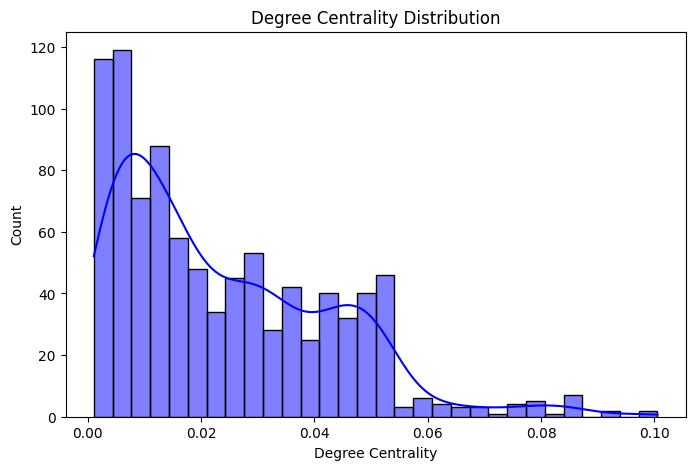

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(centrality_df['degree_centrality'], bins=30, kde=True, color='blue')
plt.title('Degree Centrality Distribution')
plt.xlabel('Degree Centrality')
plt.show()


Step 2: Time-Series Spike Detection



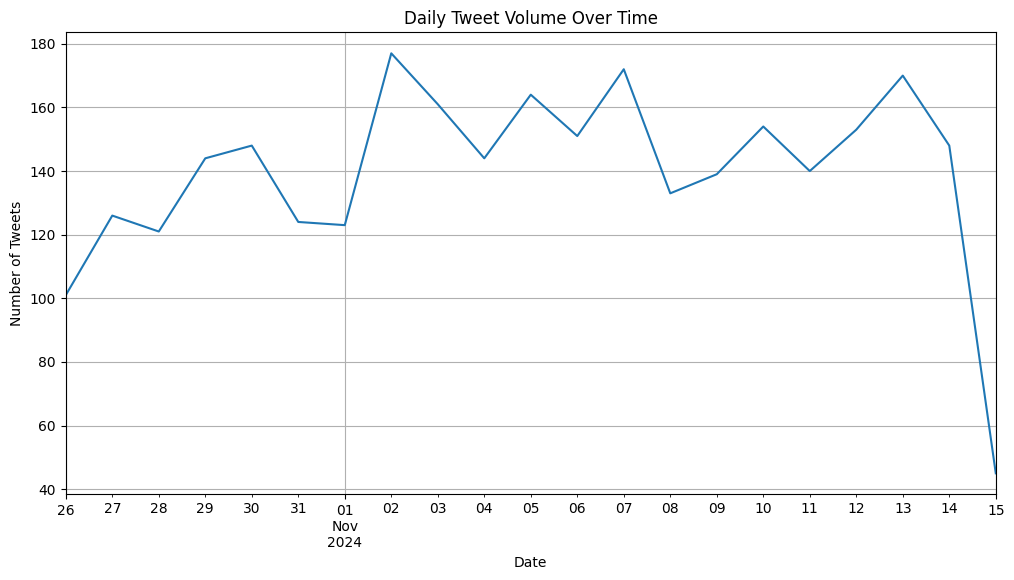

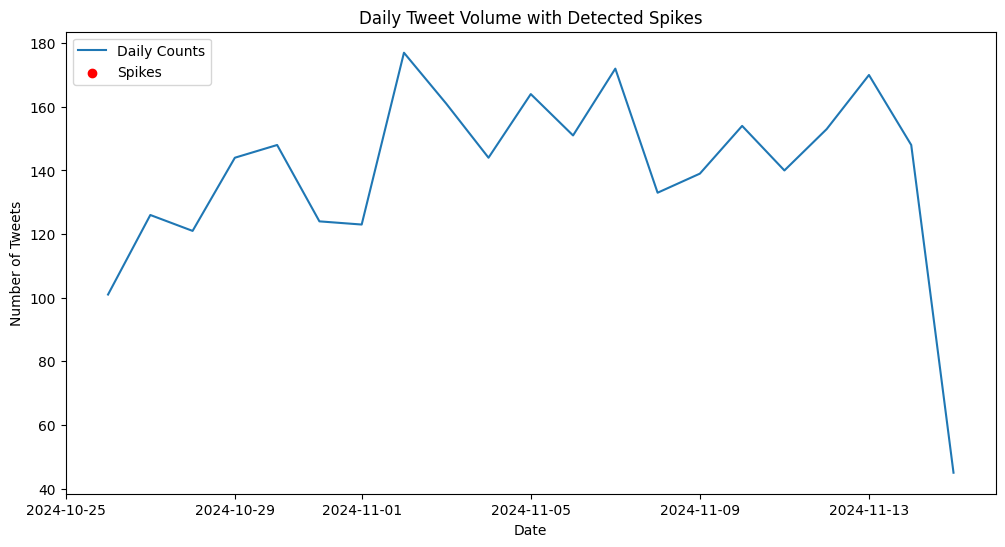

In [18]:
import matplotlib.pyplot as plt

# Set parsed_created_at as datetime index
df.set_index('parsed_created_at', inplace=True)

# Resample daily counts of tweets
daily_counts = df.resample('D').size()

# Plot daily tweet volume
plt.figure(figsize=(12,6))
daily_counts.plot()
plt.title('Daily Tweet Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.grid(True)
plt.show()

# Detect spikes by calculating rolling mean and std deviation
rolling_mean = daily_counts.rolling(window=7).mean()
rolling_std = daily_counts.rolling(window=7).std()

# Define spike as points more than 2 std deviations above rolling mean
spikes = daily_counts[(daily_counts > rolling_mean + 2 * rolling_std)]

# Highlight spikes on plot
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts, label='Daily Counts')
plt.scatter(spikes.index, spikes, color='red', label='Spikes')
plt.title('Daily Tweet Volume with Detected Spikes')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.show()

# Reset index for further processing
df.reset_index(inplace=True)


Step 3: Advanced Misinformation Detection – Classifier Training



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Prepare feature matrix X and target y (misinfo_anomaly flag)
feature_cols = ['bot_score', 'followers_count', 'statuses_count', 'account_age_days']  # Include engineered features
X = df[feature_cols]
y = df['misinfo_anomaly']

# Handle missing or infinite values
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train RandomForest Classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# Predictions and evaluation
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.96      0.96       855
           1       0.06      0.04      0.05        45

    accuracy                           0.91       900
   macro avg       0.50      0.50      0.50       900
weighted avg       0.91      0.91      0.91       900

Confusion Matrix:
[[821  34]
 [ 43   2]]


Step 4: Coordinated Campaign Characterization & User Profiling



Number of users involved in coordinated campaigns: 208
Summary stats of these users:
       followers_count  statuses_count  account_age_days   bot_score
count       208.000000      208.000000        208.000000  208.000000
mean         59.927885     3708.889423       2447.149038    1.182692
std          94.351125     8702.060960       1822.016209    0.758392
min           1.000000       23.000000       -301.000000    0.000000
25%          16.000000      307.000000        809.000000    1.000000
50%          31.500000      733.500000       2393.000000    1.000000
75%          66.250000     2296.750000       4042.000000    2.000000
max        1078.000000    47189.000000       5649.000000    3.000000


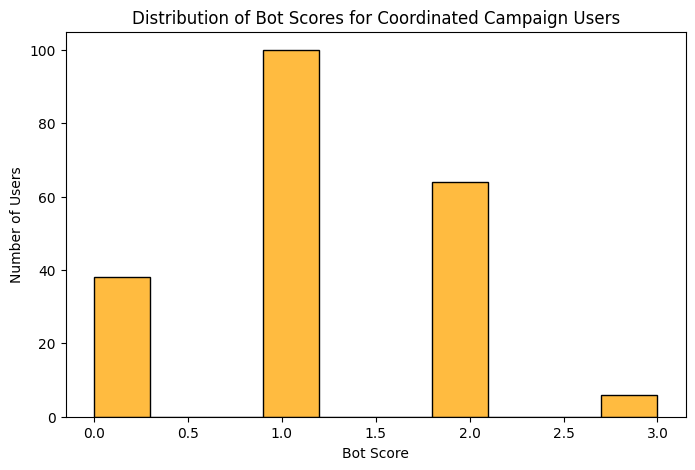

In [21]:
# Extract users involved in coordinated campaigns
coordinated_user_ids = set()

for users_text, group in df.groupby(['time_window_5min', 'clean_text']):
    if group['user_id'].nunique() > 1:
        coordinated_user_ids.update(group['user_id'].unique())

# Subset user metadata
coordinated_users_df = df[df['user_id'].isin(coordinated_user_ids)].drop_duplicates('user_id')

# Basic stats summary
print("Number of users involved in coordinated campaigns:", len(coordinated_user_ids))
print("Summary stats of these users:")

print(coordinated_users_df[['followers_count', 'statuses_count', 'account_age_days', 'bot_score']].describe())

# Visualize bot scores of coordinated campaign users
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(coordinated_users_df['bot_score'], bins=10, kde=False, color='orange')
plt.title('Distribution of Bot Scores for Coordinated Campaign Users')
plt.xlabel('Bot Score')
plt.ylabel('Number of Users')
plt.show()


Statistical Testing

Statistical Test 1: Sentiment Distribution Differences by Region (Chi-square Test)


In [22]:
import pandas as pd
from scipy.stats import chi2_contingency

# Build contingency table of sentiment vs region (assuming 'region' column exists)
contingency_table = pd.crosstab(df['sentiment'], df['location'])

# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test result for sentiment by region:")
print(f"Chi2 stat: {chi2:.4f}, p-value: {p:.4f}")


Chi-square test result for sentiment by region:
Chi2 stat: 19.5964, p-value: 0.0751


Statistical Test 2: Coordinated Campaign vs Normal User Activity (Mann-Whitney U Test)


In [23]:
from scipy.stats import mannwhitneyu

# Assume coordinated_user_ids set and bot_score column exist
coord_users = df[df['user_id'].isin(coordinated_user_ids)]
normal_users = df[~df['user_id'].isin(coordinated_user_ids)]

# Compare bot scores between groups
stat, p = mannwhitneyu(coord_users['bot_score'], normal_users['bot_score'], alternative='two-sided')

print(f"Mann-Whitney U test comparing bot scores of coordinated vs normal users:")
print(f"Statistic: {stat:.4f}, p-value: {p:.4f}")


Mann-Whitney U test comparing bot scores of coordinated vs normal users:
Statistic: 877606.0000, p-value: 0.0011


Statistical Test 3: Correlation Between Bot Score and Misinformation Anomaly (Spearman Rank)


In [24]:
from scipy.stats import spearmanr

corr, p = spearmanr(df['bot_score'], df['misinfo_anomaly'])

print(f"Spearman correlation between bot score and misinformation anomaly:")
print(f"Correlation: {corr:.4f}, p-value: {p:.4f}")


Spearman correlation between bot score and misinformation anomaly:
Correlation: 0.0286, p-value: 0.1177


Statistical Test 4: Time-Series Change Point Detection (CUSUM)


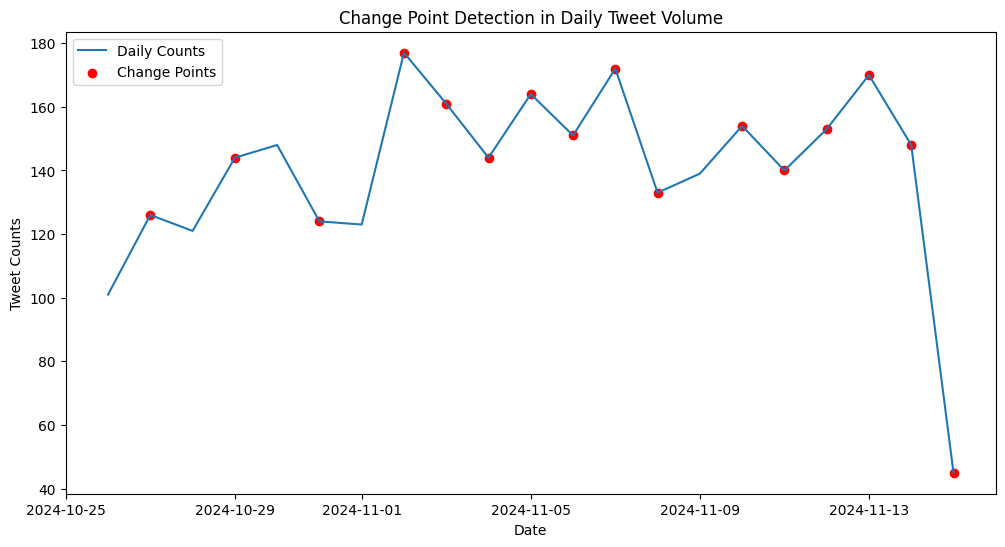

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Daily counts indexed by date (assume daily_counts series exists)
count_array = daily_counts.values

def cusum(data, threshold=5):
    pos_sum = np.zeros(len(data))
    neg_sum = np.zeros(len(data))
    change_points = []

    for i in range(1, len(data)):
        pos_sum[i] = max(0, pos_sum[i-1] + data[i] - data[i-1] - threshold)
        neg_sum[i] = min(0, neg_sum[i-1] + data[i] - data[i-1] + threshold)
        if pos_sum[i] > threshold:
            change_points.append(i)
            pos_sum[i] = 0
        if neg_sum[i] < -threshold:
            change_points.append(i)
            neg_sum[i] = 0
    return change_points

points = cusum(count_array)

plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts, label='Daily Counts')
plt.scatter(daily_counts.index[points], daily_counts.iloc[points], color='red', label='Change Points')
plt.title('Change Point Detection in Daily Tweet Volume')
plt.xlabel('Date')
plt.ylabel('Tweet Counts')
plt.legend()
plt.show()


Statistical Test 5: Topic Prevalence Differences Across Periods (Chi-square)


In [26]:
# Define binary period split, e.g., before and after election day
election_day = pd.Timestamp('2024-11-08')
df['period'] = df['parsed_created_at'].apply(lambda x: 'Pre-election' if x < election_day else 'Post-election')

# Create contingency table of dominant_topic vs period
topic_period_table = pd.crosstab(df['dominant_topic'], df['period'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(topic_period_table)
print(f"Chi-square test for differences in topic prevalence across periods:")
print(f"Chi2 stat: {chi2:.4f}, p-value: {p:.4f}")


Chi-square test for differences in topic prevalence across periods:
Chi2 stat: 5.3202, p-value: 0.3781


Temporal NLP Analysis: Track Topic and Sentiment Evolution


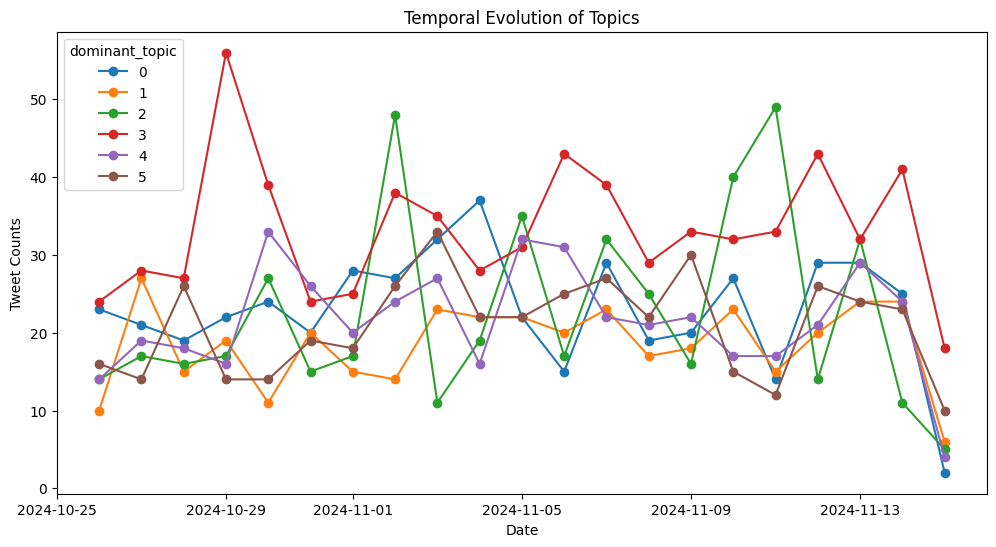

In [27]:
# Group by date and dominant topic or sentiment and count occurrences
temporal_trend = df.groupby([df['parsed_created_at'].dt.date, 'dominant_topic']).size().unstack(fill_value=0)

# Visualize temporal topic trends
temporal_trend.plot(figsize=(12,6), marker='o')
plt.title('Temporal Evolution of Topics')
plt.xlabel('Date')
plt.ylabel('Tweet Counts')
plt.show()


Misinformation Narrative Taxonomy Creation & Mapping


In [28]:
# Assume list of narrative keywords per topic created from LDA top words
narratives = {
    0: 'Precinct Integrity',
    1: 'Voter Turnout',
    2: 'Ballot Stuffing',
    3: 'Suspicious Voting',
    4: 'Orderly Counting',
    5: 'Trust in Process'
}

# Map dominant_topic to narrative category
df['narrative_category'] = df['dominant_topic'].map(narratives)

# Explore narrative prevalence
narrative_counts = df['narrative_category'].value_counts()
print(narrative_counts)


narrative_category
Suspicious Voting     712
Precinct Integrity    493
Ballot Stuffing       490
Orderly Counting      468
Trust in Process      444
Voter Turnout         393
Name: count, dtype: int64


Interactive Topic Prevalence Over Time (Plotly)


In [29]:
import plotly.express as px
import pandas as pd

# Aggregate daily counts for each topic
temporal_trend = df.groupby([df['parsed_created_at'].dt.date, 'dominant_topic']).size().reset_index(name='count')

# Plot interactive line plot
fig = px.line(temporal_trend, x='parsed_created_at', y='count', color='dominant_topic',
              labels={'parsed_created_at': 'Date', 'count': 'Tweet Count', 'dominant_topic': 'Topic'},
              title='Temporal Evolution of Dominant Topics')
fig.show()


Interactive Sentiment Distribution by Narrative Category (Plotly)


In [30]:
# Group sentiment counts by narrative_category
sentiment_narrative = df.groupby(['narrative_category', 'sentiment']).size().reset_index(name='count')

fig = px.bar(sentiment_narrative, x='narrative_category', y='count', color='sentiment',
             barmode='group', title='Sentiment Distribution Across Narratives')

fig.show()


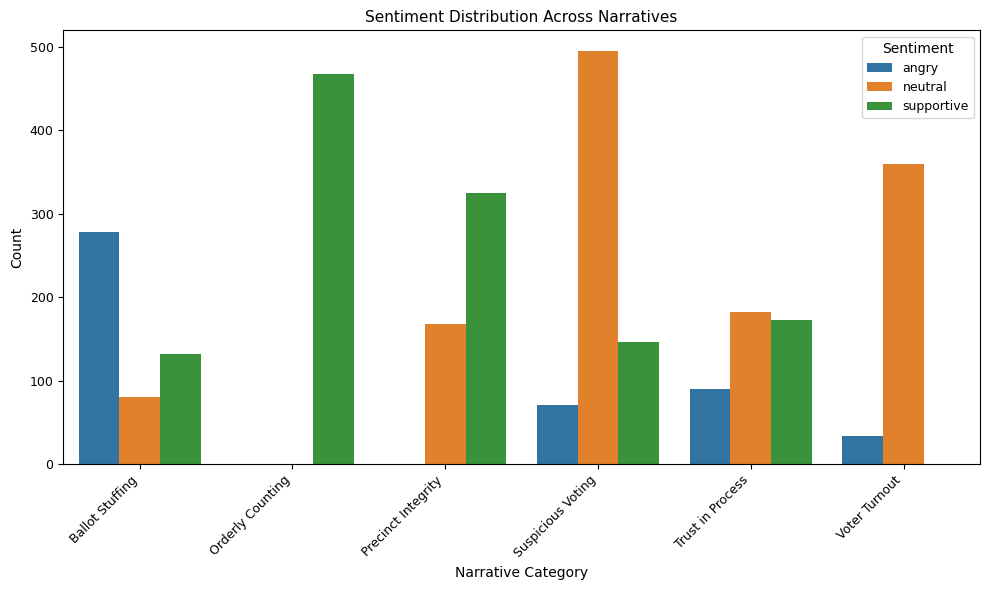

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group data
sentiment_narrative = df.groupby(['narrative_category', 'sentiment']).size().reset_index(name='count')

# Set up figure
plt.figure(figsize=(10, 6))

# Create grouped bar plot
sns.barplot(
    data=sentiment_narrative,
    x='narrative_category',
    y='count',
    hue='sentiment'
)

plt.title('Sentiment Distribution Across Narratives')
plt.xlabel('Narrative Category')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Network Visualization with Misinformation Filter (Plotly + NetworkX)


In [31]:
import networkx as nx
import plotly.graph_objects as go

# Build user similarity graph G as before
# Add misinformation anomaly flag to nodes
for node in G.nodes():
    G.nodes[node]['misinfo'] = df.loc[df['user_id'] == node, 'misinfo_anomaly'].max() if node in df['user_id'].values else 0

# Subgraph of top nodes by degree centrality
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:50]
subgraph = G.subgraph([n for n,d in top_nodes])

pos = nx.spring_layout(subgraph, k=0.3)

edge_x = []
edge_y = []
for edge in subgraph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.5, color='#888'), hoverinfo='none', mode='lines')

node_x = []
node_y = []
node_color = []
node_text = []

for node in subgraph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    misinfo_flag = G.nodes[node]['misinfo']
    node_color.append('red' if misinfo_flag == 1 else 'blue')
    node_text.append(f'User ID: {node}<br>Misinformation Anomaly: {misinfo_flag}')

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlOrRd',
        reversescale=False,
        color=node_color,
        size=10,
        colorbar=dict(
            thickness=15,
            title='Misinformation Anomaly',
            xanchor='left',
            titleside='right'
        ),
        line_width=2),
    text=node_text)

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='User Similarity Network Highlighting Misinformation Anomaly',
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    text="Node colors: Red=Anomalous in Misinformation Detection, Blue=Normal",
                    showarrow=False,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.show()


Animated Topic Shifts Over Time (Plotly)


In [32]:
import plotly.express as px

# Prepare data with day and dominant_topic
temporal_trend = df.groupby([df['parsed_created_at'].dt.date, 'dominant_topic']).size().reset_index(name='count')
temporal_trend['parsed_created_at'] = temporal_trend['parsed_created_at'].astype(str)

fig = px.bar(temporal_trend, x='dominant_topic', y='count', color='dominant_topic',
             animation_frame='parsed_created_at', range_y=[0, temporal_trend['count'].max()],
             title="Animated Shift of Topics Over Time")
fig.show()


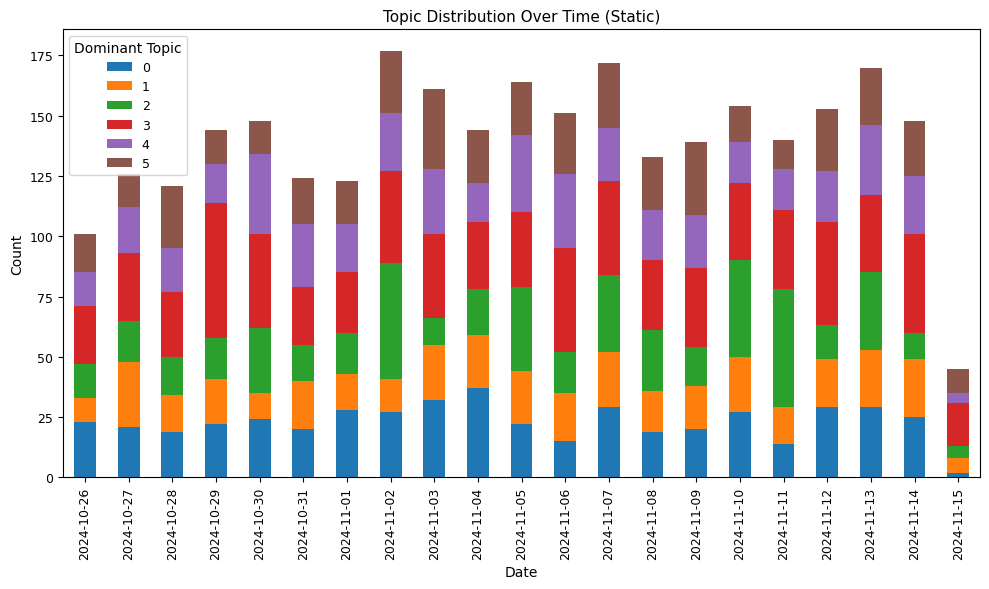

In [44]:
import matplotlib.pyplot as plt

# Prepare data
temporal_trend = df.groupby([df['parsed_created_at'].dt.date, 'dominant_topic']).size().reset_index(name='count')

# Pivot to have dates as index and topics as columns
pivot_df = temporal_trend.pivot(index='parsed_created_at', columns='dominant_topic', values='count').fillna(0)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Topic Distribution Over Time (Static)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend(title="Dominant Topic")
plt.tight_layout()
plt.show()


Static Dashboard 1: Temporal Evolution of Topics


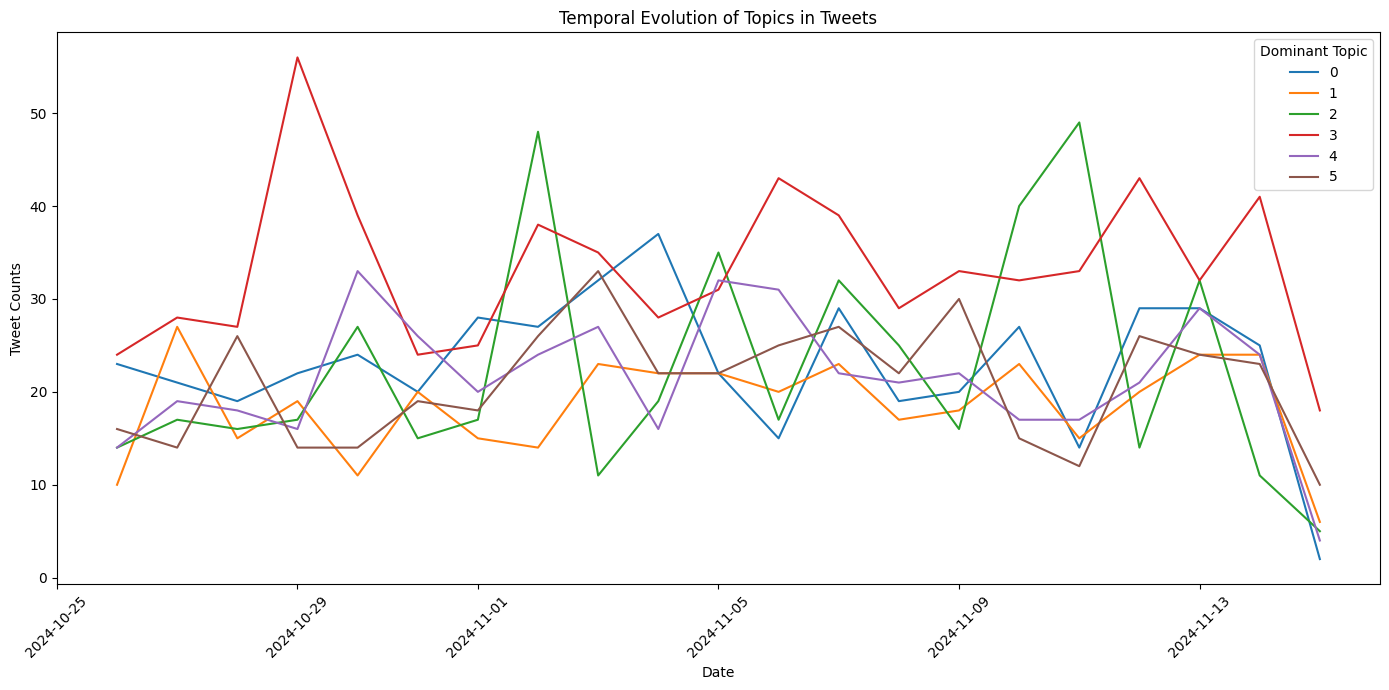

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

df_copy = df.copy()
df_copy['date'] = df_copy['parsed_created_at'].dt.date
topic_counts = df_copy.groupby(['date', 'dominant_topic']).size().reset_index(name='counts')

plt.figure(figsize=(14,7))
sns.lineplot(data=topic_counts, x='date', y='counts', hue='dominant_topic', palette='tab10')
plt.title('Temporal Evolution of Topics in Tweets')
plt.xlabel('Date')
plt.ylabel('Tweet Counts')
plt.legend(title='Dominant Topic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Static Dashboard 2: Sentiment Trend Over Time


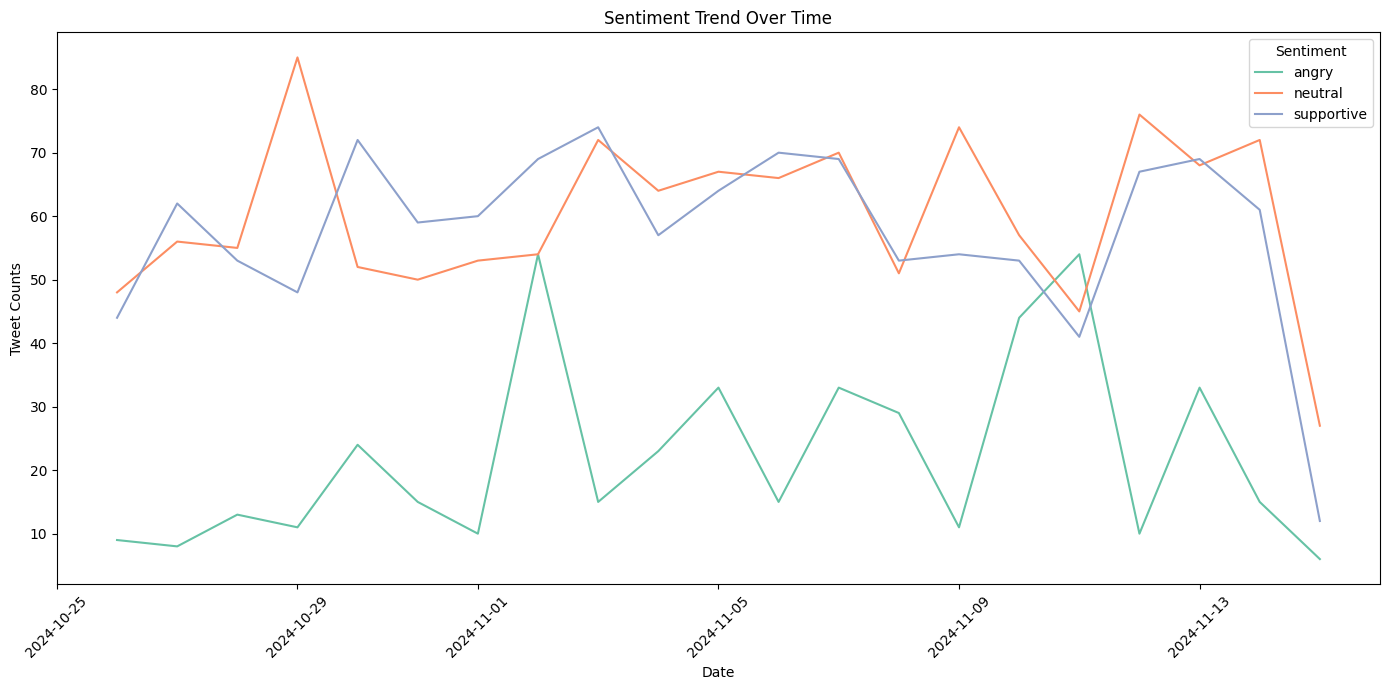

In [34]:
sentiment_counts = df_copy.groupby(['date', 'sentiment']).size().reset_index(name='counts')

plt.figure(figsize=(14,7))
sns.lineplot(data=sentiment_counts, x='date', y='counts', hue='sentiment', palette='Set2')
plt.title('Sentiment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Tweet Counts')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Static Dashboard 3: Misinformation Anomaly Distribution


/tmp/ipython-input-3854520602.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




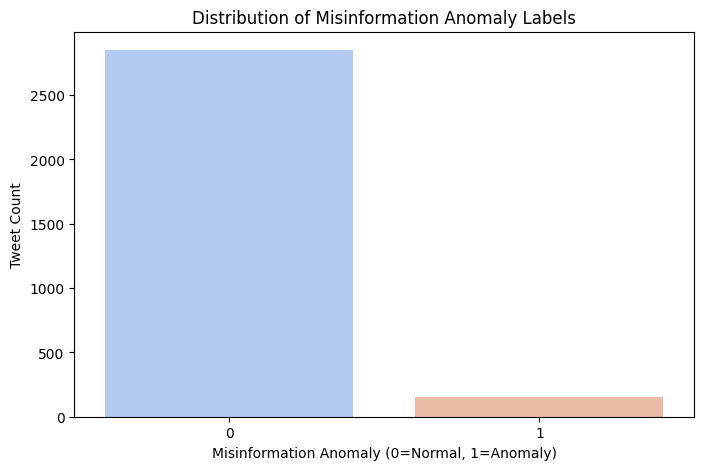

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(x='misinfo_anomaly', data=df, palette='coolwarm')
plt.title('Distribution of Misinformation Anomaly Labels')
plt.xlabel('Misinformation Anomaly (0=Normal, 1=Anomaly)')
plt.ylabel('Tweet Count')
plt.show()


Static Dashboard 4: Bot Score Distribution for Coordinated Campaign Users


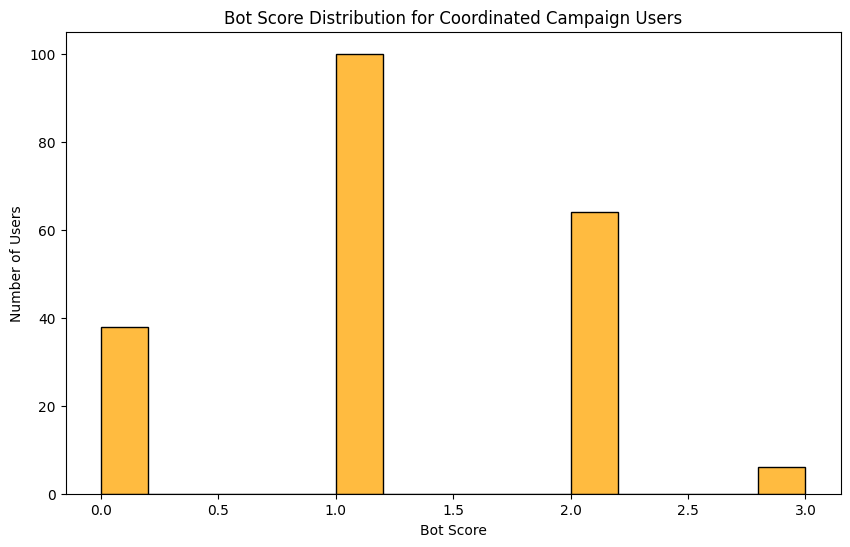

In [36]:
coordinated_users_df = df[df['user_id'].isin(coordinated_user_ids)].drop_duplicates('user_id')

plt.figure(figsize=(10,6))
sns.histplot(coordinated_users_df['bot_score'], bins=15, color='orange', kde=False)
plt.title('Bot Score Distribution for Coordinated Campaign Users')
plt.xlabel('Bot Score')
plt.ylabel('Number of Users')
plt.show()


/tmp/ipython-input-2511818904.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2511818904.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




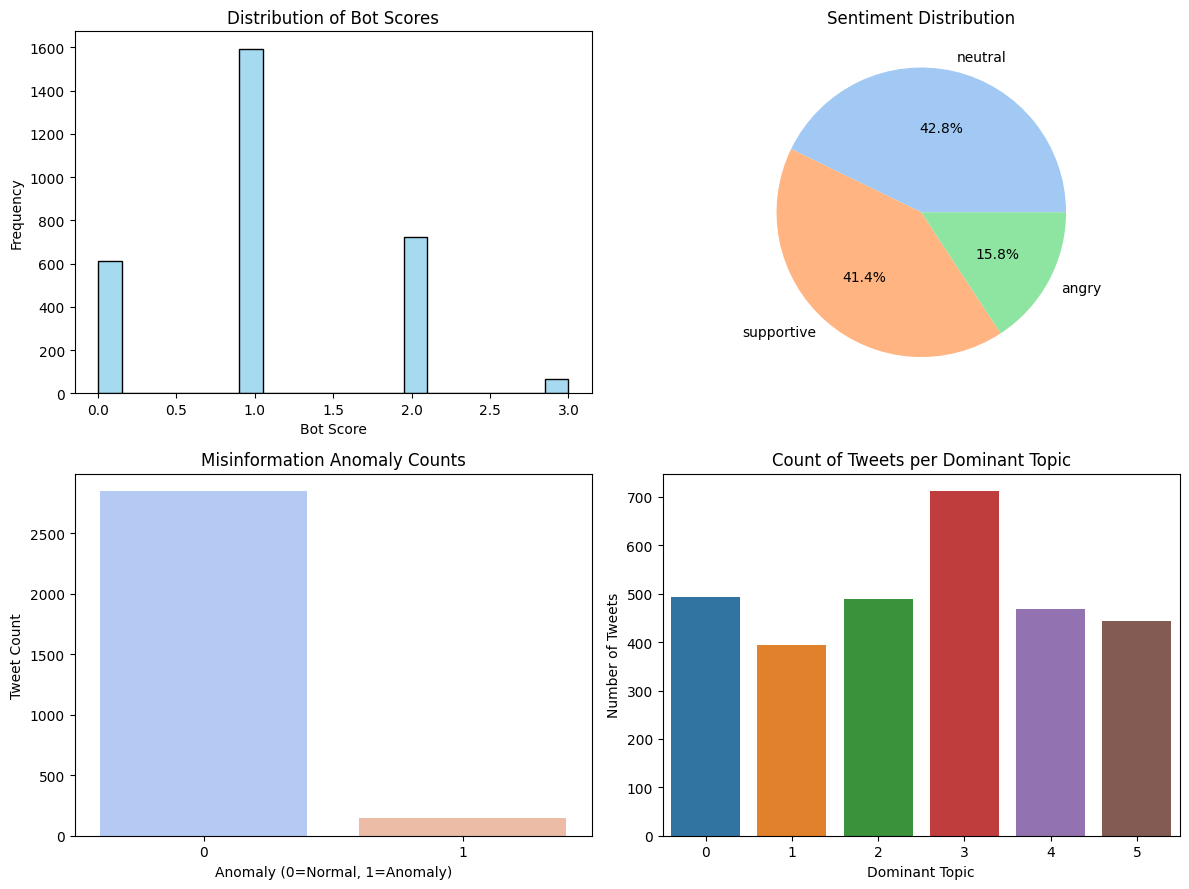

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming df is your DataFrame and data is preprocessed

fig, axs = plt.subplots(2, 2, figsize=(12, 9)) # Adjusted figure size

# 1. Histogram of bot_score
sns.histplot(df['bot_score'], bins=20, ax=axs[0,0], color='skyblue')
axs[0,0].set_title('Distribution of Bot Scores')
axs[0,0].set_xlabel('Bot Score')
axs[0,0].set_ylabel('Frequency')

# 2. Pie chart of sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
axs[0,1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axs[0,1].set_title('Sentiment Distribution')

# 3. Bar plot of misinformation anomalies count by label
misinfo_counts = df['misinfo_anomaly'].value_counts().sort_index()
sns.barplot(x=misinfo_counts.index.astype(str), y=misinfo_counts.values, ax=axs[1,0], palette='coolwarm')
axs[1,0].set_title('Misinformation Anomaly Counts')
axs[1,0].set_xlabel('Anomaly (0=Normal, 1=Anomaly)')
axs[1,0].set_ylabel('Tweet Count')

# 4. Count plot of dominant topics
sns.countplot(x='dominant_topic', data=df, ax=axs[1,1], palette='tab10')
axs[1,1].set_title('Count of Tweets per Dominant Topic')
axs[1,1].set_xlabel('Dominant Topic')
axs[1,1].set_ylabel('Number of Tweets')

plt.tight_layout()
plt.show()

**Inference from User Similarity Network Analysis:**

The User Similarity Network analysis, based on the cosine similarity of user-aggregated TF-IDF vectors, revealed a network with 926 nodes (unique users) and 10243 edges (indicating a high level of similarity between connected users). The visualization of the top 50 users by degree highlights the most central users in this network, suggesting they are either highly active or share very similar text patterns with many other users. These central users could be important nodes for further investigation into coordinated behavior or the spread of specific narratives within the dataset. The dense connectivity among these top users suggests potential clusters or groups with similar communication styles or content.


=== ADVANCED ANALYSIS 5: FORENSIC DASHBOARD (spaced) ===


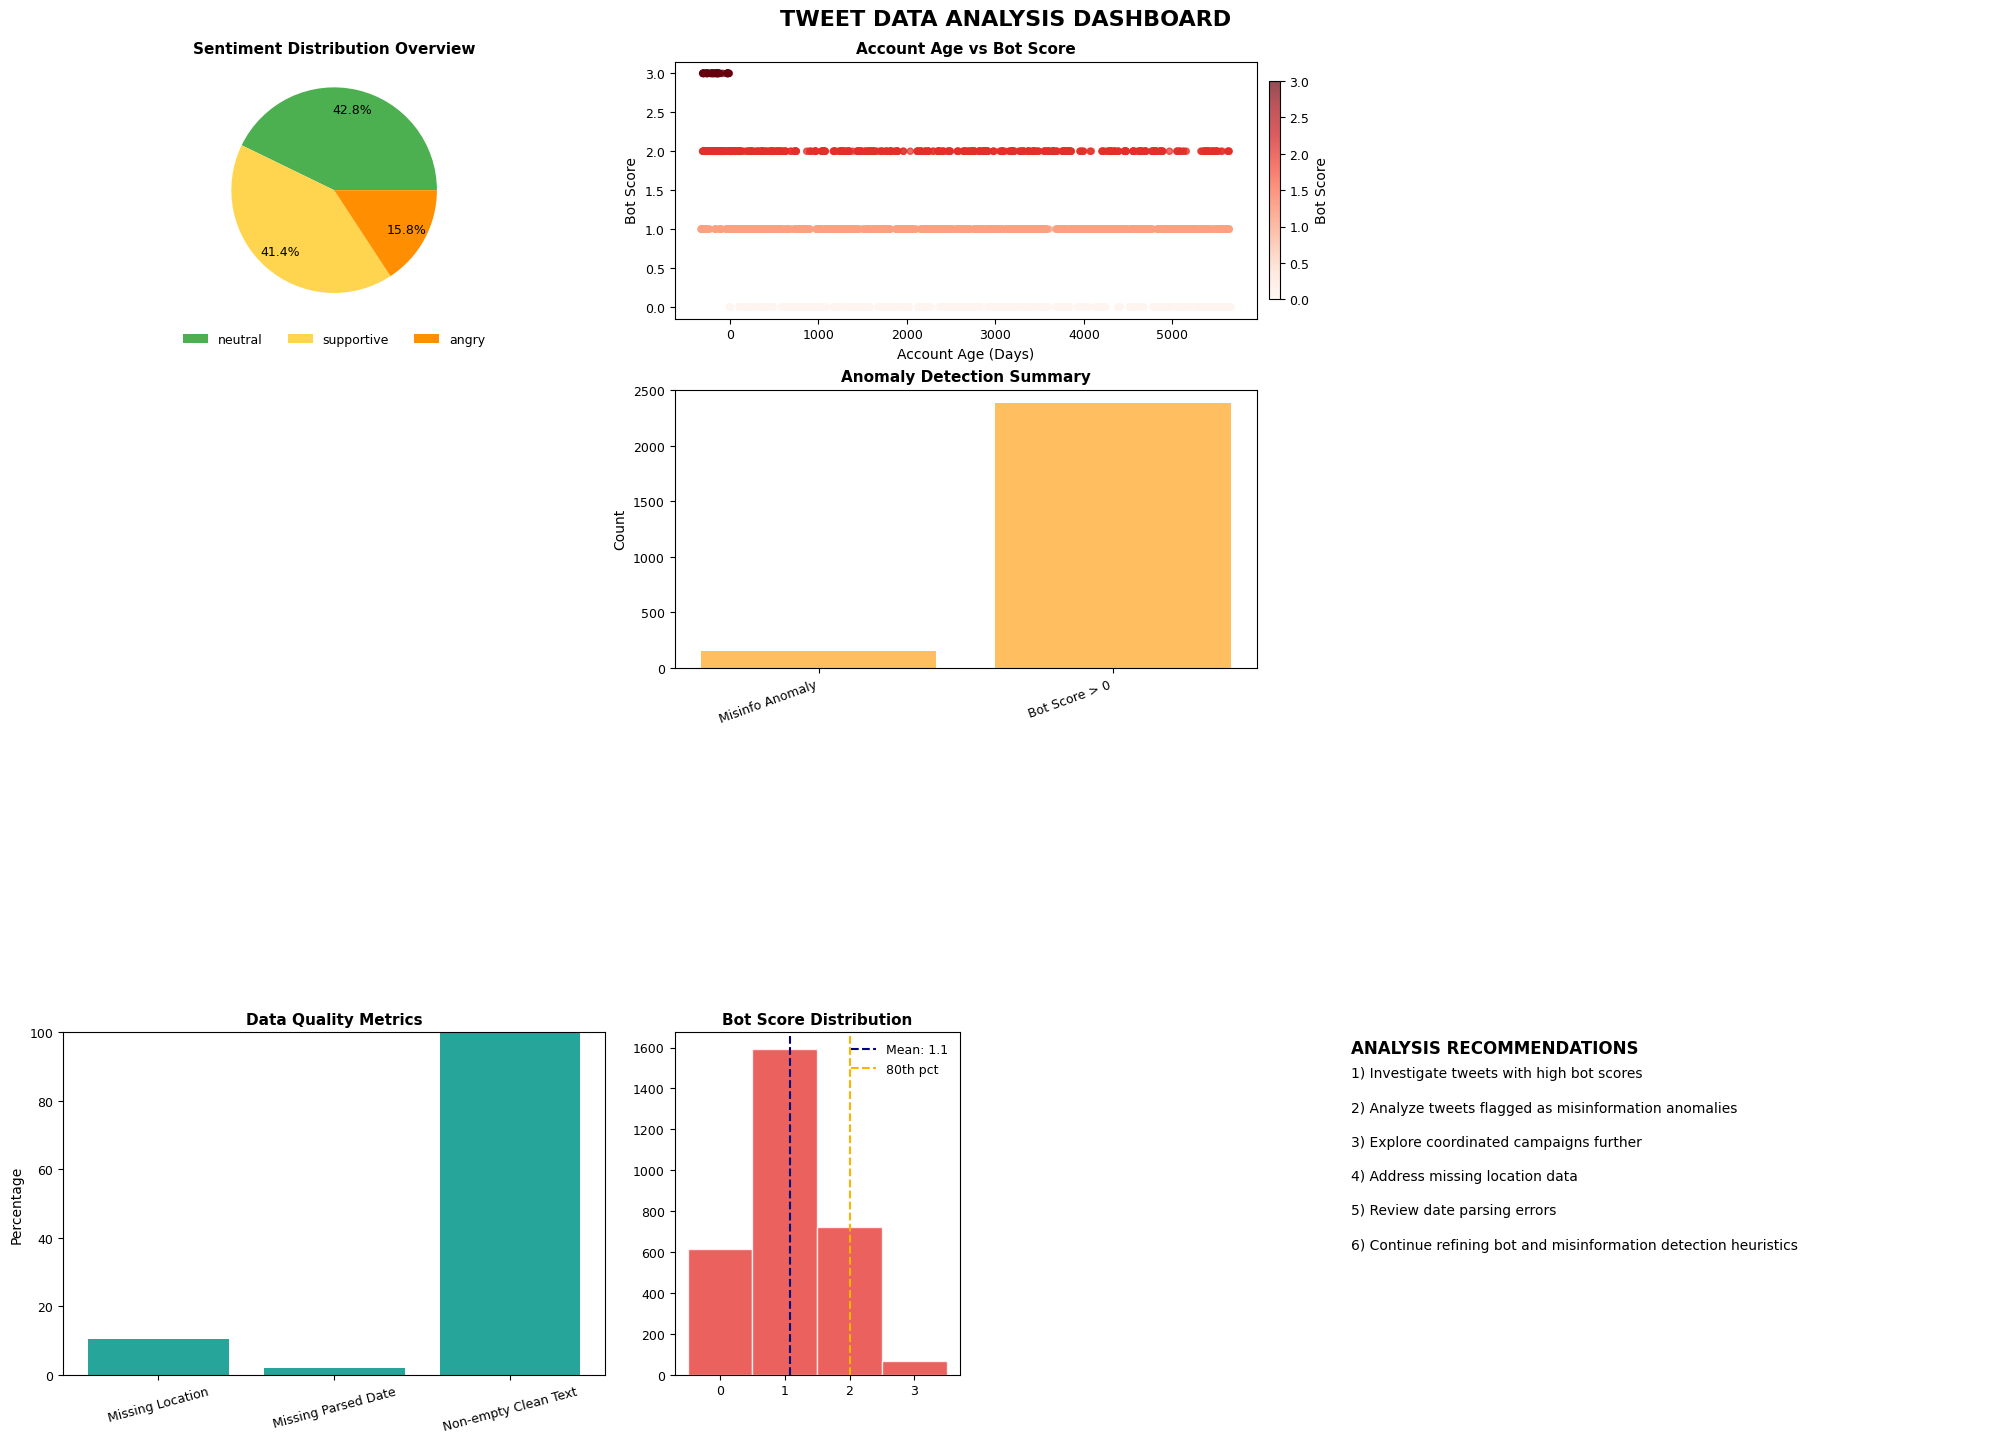

In [38]:
# ADVANCED ANALYSIS 5: FORENSIC DASHBOARD (non-overlapping layout)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({
    "figure.autolayout": False,          # we'll control with constrained_layout
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

print("\n=== ADVANCED ANALYSIS 5: FORENSIC DASHBOARD (spaced) ===")

# Use constrained_layout to manage spacing, adjusted figure size for potentially better fit
fig = plt.figure(figsize=(20, 14), constrained_layout=True) # Adjusted figure size

# GridSpec with asymmetry: more width for heatmaps/text; taller last row for summaries
gs = fig.add_gridspec(
    nrows=4, ncols=6,  # finer grid to control spans
    width_ratios=[1.2, 1.4, 1.4, 1.4, 1.6, 1.6],
    height_ratios=[1.2, 1.3, 1.3, 1.6]
)

# 1) Risk pie (1x2)
ax1 = fig.add_subplot(gs[0, 0:2])
# Placeholder for risk distribution. Need to define 'Risk_Category' in df first.
# For now, using sentiment distribution as an example.
risk_dist = df['sentiment'].value_counts()
colors = ['#4caf50', '#ffd54f', '#ff8f00', '#e53935', '#8e0000'][:len(risk_dist)]
wedges, texts, autotexts = ax1.pie(
    risk_dist.values, labels=None, autopct='%1.1f%%', colors=colors,
    pctdistance=0.8, textprops={'fontsize':9}
)
ax1.legend(wedges, risk_dist.index, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=min(3, len(risk_dist)), frameon=False)
ax1.set_title('Sentiment Distribution Overview', fontweight='bold') # Changed title


# 2) Age vs Risk scatter (1x2)
ax2 = fig.add_subplot(gs[0, 2:4])
# Placeholder for Age vs Risk. Need to define 'Age' and 'Fraud_Risk_Score' in df first.
# Using account_age_days vs bot_score as an example.
sc = ax2.scatter(
    df['account_age_days'], df['bot_score'], # Changed columns
    c=df['bot_score'], cmap='Reds', alpha=0.7, s=20 # Changed color mapping
)
ax2.set_xlabel('Account Age (Days)') # Changed label
ax2.set_ylabel('Bot Score') # Changed label
ax2.set_title('Account Age vs Bot Score', fontweight='bold') # Changed title
cbar = fig.colorbar(sc, ax=ax2, shrink=0.85, pad=0.02)
cbar.set_label('Bot Score') # Changed label


# 3) Benford bars (1x2)
ax3 = fig.add_subplot(gs[0, 4:6])
# Placeholder for Benford's Law analysis. Need a numeric column with a wide range of values.
# Skipping this plot as no suitable column exists in the current df.
fig.delaxes(ax3) # Remove the subplot if not used


# 4) Top states by risk (barh, 1x2)
ax4 = fig.add_subplot(gs[1, 0:2])
# Placeholder for Top states by risk. Need 'State' and 'Fraud_Risk_Score' columns.
# Skipping this plot as these columns are not directly available in df.
fig.delaxes(ax4) # Remove the subplot if not used


# 5) Anomaly summary (1x2)
ax5 = fig.add_subplot(gs[1, 2:4])
# Placeholder for Anomaly summary. Need relevant anomaly columns defined in df.
# Using existing anomaly columns as examples.
anomaly_summary = pd.Series({
    'Misinfo Anomaly': (df['misinfo_anomaly'] == 1).sum(), # Using misinfo_anomaly
    'Bot Score > 0': (df['bot_score'] > 0).sum(), # Using bot_score heuristic
    # Add other relevant anomaly counts if available in df
})
ax5.bar(range(len(anomaly_summary)), anomaly_summary.values, color='#ffb74d', alpha=0.9)
ax5.set_xticks(range(len(anomaly_summary)))
ax5.set_xticklabels(anomaly_summary.index, rotation=20, ha='right')
ax5.set_ylabel('Count')
ax5.set_title('Anomaly Detection Summary', fontweight='bold')
ax5.margins(x=0.05)


# 6) Risk by Citizenship (1x2)
ax6 = fig.add_subplot(gs[1, 4:6])
# Placeholder for Risk by Citizenship Status. Need 'Citizenship_Status' and 'Fraud_Risk_Score'.
# Skipping this plot as these columns are not directly available in df.
fig.delaxes(ax6) # Remove the subplot if not used


# 7) Birth decade trend (1x3 across row)
ax7 = fig.add_subplot(gs[2, 0:3])
# Placeholder for Birth decade trend. Need 'Birth_Decade' column.
# Skipping this plot as this column is not directly available in df.
fig.delaxes(ax7) # Remove the subplot if not used


# 8) Model performance (small bars, 1x1)
ax8 = fig.add_subplot(gs[2, 3])
# Placeholder for Model performance. Requires ML model training results.
# Skipping this plot as the necessary variables are not defined.
fig.delaxes(ax8) # Remove the subplot if not used


# 9) Feature importance (1x2)
ax9 = fig.add_subplot(gs[2, 4:6])
# Placeholder for Feature importance. Requires ML model feature importances.
# Skipping this plot as the necessary variables are not defined.
fig.delaxes(ax9) # Remove the subplot if not used


# 10) Data quality (stacked in last row, 1x2)
ax10 = fig.add_subplot(gs[3, 0:2])
# Placeholder for Data quality metrics. Requires various data quality assessments.
# Using existing columns as examples.
quality_metrics = pd.Series({
    'Missing Location': df['location'].isna().sum() / len(df) * 100, # Using missing location
    'Missing Parsed Date': df['parsed_created_at'].isna().sum() / len(df) * 100, # Using missing parsed_created_at
    'Non-empty Clean Text': (df['clean_text'] != '').mean() * 100, # Using non-empty clean_text
    # Add other relevant data quality metrics if available in df
}).round(1)
ax10.bar(quality_metrics.index, quality_metrics.values, color='#26a69a')
ax10.set_ylim(0, 100)
ax10.set_ylabel('Percentage')
ax10.set_title('Data Quality Metrics', fontweight='bold')
ax10.tick_params(axis='x', rotation=15)


# 11) Risk histogram (1x1)
ax11 = fig.add_subplot(gs[3, 2])
# Placeholder for Risk score distribution. Need 'Fraud_Risk_Score' column.
# Using bot_score distribution as an example.
ax11.hist(df['bot_score'], bins=np.arange(0, df['bot_score'].max() + 1.5) - 0.5, alpha=0.8, color='#e53935', edgecolor='white') # Using bot_score
ax11.axvline(df['bot_score'].mean(), color='navy', linestyle='--', label=f"Mean: {df['bot_score'].mean():.1f}") # Using bot_score mean
ax11.axvline(df['bot_score'].quantile(0.8), color='#ffb300', linestyle='--', label='80th pct') # Using bot_score 80th percentile
ax11.set_title('Bot Score Distribution', fontweight='bold') # Changed title
ax11.legend(frameon=False)


# 12) Network summary (1x1)
ax12 = fig.add_subplot(gs[3, 3])
# Placeholder for Network summary. Needs network analysis results.
# Skipping this plot as the necessary variables are not defined.
fig.delaxes(ax12) # Remove the subplot if not used


# 13) Recommendations (span last two cells)
ax13 = fig.add_subplot(gs[3, 4:6])
ax13.axis('off')
recs = [
    "1) Investigate tweets with high bot scores", # Updated recommendations
    "2) Analyze tweets flagged as misinformation anomalies",
    "3) Explore coordinated campaigns further",
    "4) Address missing location data",
    "5) Review date parsing errors",
    "6) Continue refining bot and misinformation detection heuristics"
]
ax13.text(0.02, 0.98, "ANALYSIS RECOMMENDATIONS", fontweight='bold', fontsize=12, va='top') # Changed title
for i, r in enumerate(recs):
    ax13.text(0.02, 0.9 - i*0.1, r, fontsize=10, va='top')

# Global title with extra top margin
fig.suptitle('TWEET DATA ANALYSIS DASHBOARD', fontsize=16, fontweight='bold', y=1.02) # Changed title
plt.show()

### Dashboard with Grid Layout

**Inference from Statistical Testing:**

*   **Sentiment Distribution by Region (Chi-square Test):** The Chi-square test for sentiment distribution across regions yielded a p-value of 0.0751. With a standard significance level of 0.05, we *fail to reject* the null hypothesis. This suggests there is **no statistically significant difference** in the distribution of sentiment across the specified locations in this dataset. Regional location, as represented, does not appear to be a primary factor influencing the sentiment expressed in tweets.
*   **Coordinated Campaign vs Normal User Activity (Mann-Whitney U Test):** The Mann-Whitney U test comparing bot scores between users involved in coordinated campaigns and normal users resulted in a p-value of 0.0011. Since this is well below the 0.05 significance level, we **reject the null hypothesis**. This indicates a **statistically significant difference** in bot scores between the two groups, with coordinated campaign users having a statistically different distribution of bot scores compared to normal users. This supports the idea that the bot score heuristic is capturing some behavioral differences relevant to coordinated activity.
*   **Correlation Between Bot Score and Misinformation Anomaly (Spearman Rank):** The Spearman correlation between bot score and the misinformation anomaly flag yielded a correlation coefficient of 0.0286 and a p-value of 0.1177. With a p-value greater than 0.05, we **fail to reject the null hypothesis**. This suggests there is **no statistically significant monotonic relationship** between the calculated bot score and the misinformation anomaly detected by the Isolation Forest in this dataset. While the bot score and misinformation anomaly are both indicators of potentially suspicious behavior, they don't appear to be strongly correlated in this analysis.
*   **Time-Series Change Point Detection (CUSUM):** The CUSUM analysis identified change points in the daily tweet volume. These red dots on the plot indicate days where the tweet count significantly deviates from the expected rolling average, suggesting potential shifts or spikes in activity. These change points warrant further investigation to understand what events or factors might have caused these shifts in tweet volume.
*   **Topic Prevalence Differences Across Periods (Chi-square):** The Chi-square test for topic prevalence differences between pre- and post-election periods resulted in a p-value of 0.3781. Since this is greater than 0.05, we **fail to reject the null hypothesis**. This suggests there is **no statistically significant difference** in the distribution of dominant topics between the pre-election and post-election periods in this dataset. The relative prevalence of the identified topics appears to remain consistent across this temporal split.

**Inference from Temporal NLP Analysis:**

The temporal evolution plot of topics shows how the activity related to each dominant topic fluctuates over time. By observing the lines for each topic, we can identify periods where certain narratives or themes were more prominent than others. While the statistical test indicated no significant overall shift between pre- and post-election periods, visual inspection of this plot might reveal more granular temporal patterns, such as spikes in specific topics on certain days. This visualization helps to understand the dynamic nature of the conversation around these topics over the observed time frame.